# TO DO (URGENT)
[O] 1. CURRENLTY p=1 FIXED (DUE TO ONE-STEP PREDICTION ONLY) - Now accept p>1

[O] 2. Fix the testing part = number is wrong - It is actually correct

[O] 3. NEW LOSS: MAG EIG = 1

[ ] 4. NEW LOSS: DIST BTW MODE MAXIMIZE (Orthogonality based on MC integral?)

    => 4.A Conjugate module generation, not just each mode

    => 4.B Should I maximize the dist btw 'each mode', or conjugate wise?

[ ] 5. Wandb

# TO DO (OPTIONAL, LATER)
1. RESOLVE DECODER LIMITATION? observable_dim SHOULD BE QUITE SMALL THAN NOW
2. Consider mode combinations? -> isn't it automatically done by MOE?

Libraries

In [ ]:
import os
import sys
sys.path.append('/dataset/')
sys.path.append("../src_re") 

import math
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.nn.utils import parameters_to_vector
from scipy.linalg import eig, inv
from torch.utils.tensorboard import SummaryWriter
from torch.nn.utils.stateless import functional_call
from tensorboard import notebook
from datetime import datetime
from tqdm import tqdm
import wandb

# KAE
from Autoencoder import KoopmanAutoencoder
from Autoencoder_functions import *
from state_extract import *

# Cartpole
from test_cartpole_function import *
from models.MLP import CartpoleMLP



Parameters

In [ ]:
# Use GPU
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cuda:0')
print('Currently using... '+str(device))

# Load pre-trained KAE?
load_model = False
load_model_name = 'Your_model_name.pt'

# KAE parameters
observable_dim = 8 # observable dim
padded_dimension = 128 # MUST BE BIGGER THAN ANY STATE DIMENSION (INPUT, OUPTUT, INTERNAL)
kae_size = 32 # size of KAE
c1, c2, c3 = 1, 1, 1 # KAE loss parameters
p = 3 # KAE prediction step
loss_dist_mc_sample_num = 5 # number of MC integral samples
### -------------------- Loss coefficient
kae_coef = 0.7
# task_coef = 1/10000
task_coef = -1 # NO LOSS_TASK NOW!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
eig_coef = 0.2
dist_coef = 0.1

# Data & Training parameter
training_data_generation_loop = 15000 # how many loop you will run to generate the data
                                      # NOT NUMBER OF TRAINING DATA: that is 'training_data_size'
batch_size = 256 # 128
lr_kae = 1e-4
num_epochs = 2500
num_episodes_for_loss_task = 5 # test number during training (=validation set)
waypoint_period = 5 # Check score every this epoch and update waypoint
check_performance = False # Check performance before update the waypoint?
clip = True # clip gradient norm?

# Cartpole parameters
original_model_name = 'ppo_cartpole_policy.pt'
state_bound_lo = torch.tensor([-4.8, -10, -0.418, -3.0], device=device) # pos, vel, angle, angluar vel
state_bound_hi = torch.tensor([ 4.8,  10,  0.418,  3.0], device=device) # pos, vel, angle, angluar vel
env = gym.make("CartPole-v1")
num_episodes = 20 # test number for validation
max_reward = 500 # possible maximum reward
reward_margin = max_reward*0.01 # allow this much reward decrease

# INitialization
training_data_size = training_data_generation_loop*p # size of training dataset
obs_dim = env.observation_space.shape[0]
act_dim = env.action_space.n
Info = [observable_dim, padded_dimension, kae_size, kae_coef, eig_coef, dist_coef, p, 'CARTPOLE_v1']
print('obs dim: '+str(obs_dim) + ' / act dim: '+str(act_dim))
if padded_dimension < obs_dim or padded_dimension < act_dim:
    print('ERROR, PADDED DIMENSION MUST BE BIGGER')
    exit()

original_model = CartpoleMLP(obs_dim, act_dim).to(device)

Fixed parameters & Initialization

In [ ]:
## Set training to be deterministic
seed = 10
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ['PYTHONHASHSEED'] = str(seed)

## LOAD TRAINED MODEL
if os.path.isfile('../saved_models_re/originals/'+original_model_name):
    state_dict = torch.load('../saved_models_re/originals/'+original_model_name, weights_only=True, map_location=device)
    original_model.load_state_dict(state_dict)
    print('load '+original_model_name)
    
    # TEST PERFORMANCE OF LOADED MODEL
    # print('testing model')
    # test_cartpole_function('../saved_models_re/originals/'+original_model_name, save_imgs=False)

else:
    print('ERROR, NO MODEL FOUND')

## GENERATE RANDOM SAMPLE FOR KAE TRAINING
# LOAD existing dataset
# if False:
if os.path.isfile('results/Cartpole_KAE_training_samples_'+str(int(training_data_size))+'_p_'+str(p)+'.pth'):
    data_dict = torch.load('results/Cartpole_KAE_training_samples_'+str(int(training_data_size))+'_p_'+str(p)+'.pth', map_location=device)
    training_data = data_dict['training_data']
    print('dataset loaded')
else:
    training_data = []
    for i in range(training_data_generation_loop):
        random_input = torch.rand(1, obs_dim, device=device) * (state_bound_hi - state_bound_lo) + state_bound_lo
        
        if p == 1:
            outputs = original_model(random_input)            
            pad_in = torch.ones(random_input.size(0), padded_dimension - obs_dim, device=device)
            pad_out = torch.ones(outputs.size(0), padded_dimension - act_dim, device=device)
            aug_input = torch.cat([random_input, pad_in], dim=1)
            aug_output = torch.cat([outputs, pad_out], dim=1)

            # Save snapshot
            training_data.append((aug_input.detach().cpu(), aug_output.detach().cpu()))

        else:
            states = p_state_extract(original_model, random_input, p=p)
            # organize states in order: input → step_1 → step_2 → ... → output
            state_seq = [states["input"]]

            for k in sorted([k for k in states.keys() if k.startswith("step_")],
                            key=lambda x: int(x.split("_")[1])):
                state_seq.append(states[k])
            state_seq.append(states["output"])

            # build dataset: (s_i, s_{i+1})
            for j in range(len(state_seq) - 1):
                s_in, s_out = state_seq[j], state_seq[j+1]

                if s_in.size(1) > padded_dimension or s_out.size(1) > padded_dimension:
                    print("padded_dimension is too small. Internal state dims are: ", s_in.size(1)," and ", s_out.size(1))
                    # break

                pad_in = torch.ones(s_in.size(0), padded_dimension - s_in.size(1), device=device)
                pad_out = torch.ones(s_out.size(0), padded_dimension - s_out.size(1), device=device)

                aug_input = torch.cat([s_in, pad_in], dim=1)
                aug_output = torch.cat([s_out, pad_out], dim=1)

                training_data.append((aug_input.detach().cpu(), aug_output.detach().cpu()))

    # Save the generated training data
    torch.save({'training_data': training_data}, 'results/Cartpole_KAE_training_samples_'+str(int(training_data_size))+'_p_'+str(p)+'.pth')
    print('dataset generated')

## Build KAE
state_dim = padded_dimension
kae = KoopmanAutoencoder(state_dim=state_dim, hidden_dim=kae_size, observable_dim = observable_dim, device=device).to(device)
kae.train()
criterion_kae = koopman_loss
mse = torch.nn.MSELoss()
optimizer_kae = optim.Adam(kae.parameters(), lr=lr_kae)
kae.train()


print(f"Total samples: {len(training_data)}")
assert(training_data_size == len(training_data)), "data size is wrong check it."
for i, (inp, out) in enumerate(training_data[:5]):  # show first 5
    print(f"Sample {i}: input {inp.shape}, output {out.shape}")

Wandb

In [ ]:
# Connect wandb
current_date = datetime.now().strftime("%Y-%m-%d")

wandb.init(project="Koopman_decomposition",
           name = str(current_date),
           config={
            "lr_kae": lr_kae,
            "num_epochs": num_epochs,
            "batch_size": batch_size,
            "p": p,
            "c1": c1,
            "c2": c2,
            "c3": c3,
            "training_data_size": training_data_size,
            'Info': Info,
            'observable_dim': observable_dim,
            'padded_dimension': padded_dimension,
            'kae_size': kae_size,
            'kae_coef': kae_coef,
            'task_coef': task_coef,
            'eig_coef': eig_coef,
            'dist_coef': dist_coef,
            'training_data_generation_loop': training_data_generation_loop,
            'batch_size': batch_size,
            'num_episodes_for_loss_task': num_episodes_for_loss_task,
            'loss_dist_mc_sample_num': loss_dist_mc_sample_num
    })

Main training

In [ ]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

from Autoencoder import *
from Autoencoder_functions import *
from test_cartpole_function import *

## Preprocess KAE train data
train_loader = DataLoader(training_data, batch_size=batch_size, shuffle=False)
aug_input_all = torch.cat([training_data[i][0].unsqueeze(0) for i in range(len(training_data))]).to(device)
aug_output_all = torch.cat([training_data[i][1].unsqueeze(0) for i in range(len(training_data))]).to(device)

# Load model
if load_model:
    kae = torch.load('results/kae_'+load_model_name, weights_only=False, map_location=device)
    kae.to(device)
    print('model loaded')

# Or train new one
elif not load_model:
    best_reward = 0.0
    avg_loss_past = torch.inf
    for epoch in (tq_var := tqdm(range(num_epochs), desc="Training")):
        running_loss = 0.0
        running_classifier_loss = 0.0

        # Each batch
        for inner, (aug_input, aug_output) in enumerate(train_loader):
            # print(aug_input.shape, aug_output.shape)
            loss_task = 0.0
            loss_kae = 0.0
            loss_eig = 0.0
            loss_dist = 0.0

            # KAE loss
            if kae_coef > 0:
                loss_kae, _ = compute_l_kae(kae, aug_input, aug_output, c1, c2, c3, p, 
                                device, aug_input_all, aug_output_all, inner, batch_size)

            # Task loss
            if task_coef > 0:
                # loss_task = compute_l_task(kae, aug_input, aug_output, mse, device)
                reward_loss_task = test_cartpole_kae_function(kae, observable_dim, padded_dimension, p, device, mode_number = -1, num_episodes = num_episodes_for_loss_task, save_imgs = False)
                loss_task = ((reward_loss_task - max_reward)**2)

            # Eigenvalue loss
            if eig_coef > 0:
                current_K = kae.K.to(device)
                current_eig, _ = torch.linalg.eig(current_K)
                current_eig_mag = torch.abs(current_eig).to(device)
                loss_eig = mse(current_eig_mag, torch.ones(observable_dim).to(device))           

            # Mode distance loss - MC integral based orthogonality
            if dist_coef > 0:
                loss_dist = compute_l_dist(observable_dim, current_eig, loss_dist_mc_sample_num, obs_dim, state_bound_lo, state_bound_hi, 
                   padded_dimension, p, kae, device)
                # for i in range(0,observable_dim):
                #     for j in range(i, observable_dim):        
                #         if i!=j and (current_eig[i].conj()!=current_eig[j]):
                #             loss_dist_temp = torch.zeros(1).to(device)
                #             loss_dist_temp_1 = torch.zeros(1).to(device)
                #             loss_dist_temp_2 = torch.zeros(1).to(device)
                #             # print(loss_dist_temp, loss_dist_temp_1, loss_dist_temp_2)

                #             for k in range(0,loss_dist_mc_sample_num):
                #                 random_input_loss_dist = torch.rand(1, obs_dim, device=device) * (state_bound_hi - state_bound_lo) + state_bound_lo
                #                 pad_in_loss_dist = torch.ones(random_input_loss_dist.size(0), padded_dimension - obs_dim, device=device)
                #                 aug_input_loss_dist = torch.cat([random_input_loss_dist, pad_in_loss_dist], dim=1)
                #                 _,z_loss_dist,_ = kae(aug_input_loss_dist)

                #                 loss_dist_temp_1 = stt_decompose_mode(kae, z_loss_dist.T,_, i, p, propagation = True)
                #                 loss_dist_temp_2 = stt_decompose_mode(kae, z_loss_dist.T,_, j, p, propagation = True)
                #                 loss_dist_temp = loss_dist_temp + loss_dist_temp_1*loss_dist_temp_2.conj()

                #             loss_dist = loss_dist + (loss_dist_temp/loss_dist_mc_sample_num)

                # loss_dist = torch.abs(torch.sum(loss_dist).real)

            # Total loss
            loss = kae_coef * loss_kae + task_coef * loss_task + eig_coef * loss_eig + dist_coef * loss_dist

            # Update           
            optimizer_kae.zero_grad()
            loss.backward()
            if clip:
                torch.nn.utils.clip_grad_norm_(kae.parameters(), max_norm=1.0)  # Add this line here
            optimizer_kae.step()
            running_loss = running_loss + loss.detach().cpu().item()

            _, latent_x_all, _ = kae(aug_input_all)
            _, latent_y_all, _ = kae(aug_output_all)
            kae.compute_koopman_operator(latent_x_all, latent_y_all, device)
        
        current_date = datetime.now().strftime("%Y-%m-%d") 
        waypoint_name = 'waypoints/waypoint_'+str(Info)+f'_{current_date}.pth'
        file_name = 'waypoints/KAE_'+str(Info)+f'_{current_date}.pth'
        file_name_state_dict = 'waypoints/KAE_state_dict_'+str(Info)+f'_{current_date}.pt'
        avg_loss = running_loss / len(train_loader)
        tq_var.set_description(f'Epoch [{epoch+1:4d}/{num_epochs}] | Loss: {avg_loss:.3f} | loss_kae: {loss_kae:.3f} | loss_task: {loss_task:.3f} | loss_eig {loss_eig:.3f} | loss_dist {loss_dist:.3f}')

        # Wandb
        wandb.log({
            "epoch": epoch,
            "train_loss": running_loss,
            "avg_loss": avg_loss,
            "loss_kae": loss_kae,
            "loss_task": loss_task,
            "loss_eig": loss_eig,
            "loss_dist": loss_dist,
            "lr": optimizer_kae.param_groups[0]['lr']
        })

        if check_performance:
            kae.eval()
            reward = test_cartpole_kae_function(kae, observable_dim, padded_dimension, p, device, mode_number = -1, num_episodes = num_episodes, save_imgs = False)
            kae.train()

            if (epoch+1)%waypoint_period == 0:
                if (float(reward) > best_reward or float(reward >= max_reward-reward_margin)) and (avg_loss < avg_loss_past):
                    torch.save({
                    'epoch': epoch,
                    'param_kae': kae.state_dict(),
                    'optimizer_state_dict': optimizer_kae.state_dict(),
                    'ko': kae.K,
                    'Info': Info,
                    'observable_dim': observable_dim,
                    'padded_dimension': padded_dimension,
                    'kae_size': kae_size,
                    'kae_coef': kae_coef,
                    'task_coef': task_coef,
                    'eig_coef': eig_coef,
                    'dist_coef': dist_coef,
                    'lr_kae': lr_kae,
                    'training_data_generation_loop': training_data_generation_loop,
                    'batch_size': batch_size,
                    'c1': c1, 'c2': c2, 'c3': c3, 'p': p,
                    'num_episodes_for_loss_task': num_episodes_for_loss_task,
                    'loss_dist_mc_sample_num': loss_dist_mc_sample_num
                    }, waypoint_name)
                    torch.save(kae, file_name)
                    torch.save(kae.state_dict(), file_name_state_dict)
                    best_reward = reward
                    print(f'Best reward updated (Avg. of {num_episodes_for_loss_task}): {best_reward:.4f} at epoch {epoch}')
                    avg_loss_past = avg_loss
        else:
            if (epoch+1)%waypoint_period == 0:
                if (avg_loss < avg_loss_past):
                    torch.save({
                    'epoch': epoch,
                    'param_kae': kae.state_dict(),
                    'optimizer_state_dict': optimizer_kae.state_dict(),
                    'ko': kae.K,
                    'Info': Info,
                    'observable_dim': observable_dim,
                    'padded_dimension': padded_dimension,
                    'kae_size': kae_size,
                    'kae_coef': kae_coef,
                    'task_coef': task_coef,
                    'eig_coef': eig_coef,
                    'dist_coef': dist_coef,
                    'lr_kae': lr_kae,
                    'training_data_generation_loop': training_data_generation_loop,
                    'batch_size': batch_size,
                    'c1': c1, 'c2': c2, 'c3': c3, 'p': p,
                    'num_episodes_for_loss_task': num_episodes_for_loss_task,
                    'loss_dist_mc_sample_num': loss_dist_mc_sample_num
                    }, waypoint_name)
                    torch.save(kae, file_name)
                    torch.save(kae.state_dict(), file_name_state_dict)
                    avg_loss_past = avg_loss

        if math.isnan(running_loss/len(train_loader)):
            print('NAN detected')
            break
            
    current_date = datetime.now().strftime("%Y-%m-%d")
    waypoint_name = 'results/waypoint_'+str(Info)+'_'+str(epoch+1)+f'_{current_date}.pth'
    file_name = 'results/KAE_'+str(Info)+'_'+str(epoch+1)+f'_{current_date}.pth'
    file_name_state_dict = 'results/KAE_state_dict_'+str(Info)+f'_{current_date}.pt'
    torch.save({
    'epoch': epoch,
    'param_kae': kae.state_dict(),
    'optimizer_state_dict': optimizer_kae.state_dict(),
    'ko': kae.K,
    'Info': Info,
    'observable_dim': observable_dim,
    'padded_dimension': padded_dimension,
    'kae_size': kae_size,
    'kae_coef': kae_coef,
    'task_coef': task_coef,
    'eig_coef': eig_coef,
    'dist_coef': dist_coef,
    'lr_kae': lr_kae,
    'training_data_generation_loop': training_data_generation_loop,
    'batch_size': batch_size,
    'c1': c1, 'c2': c2, 'c3': c3, 'p': p,
    'num_episodes_for_loss_task': num_episodes_for_loss_task,
    'loss_dist_mc_sample_num': loss_dist_mc_sample_num
    }, waypoint_name)
    torch.save(kae, file_name) # save final model
    torch.save(kae.state_dict(), file_name_state_dict)
    print(f'Iteration finished, loss = {running_loss/len(train_loader):.4f}')

    wandb.finish()


In [ ]:
# %load_ext autoreload
# %autoreload 2
# %reload_ext autoreload

# from Autoencoder import *
# from Autoencoder_functions import *
# from test_cartpole_function import *
# # random_input = torch.rand(1, obs_dim, device=device) * (state_bound_hi - state_bound_lo) + state_bound_lo
# # outputs = original_model(random_input)            
# # pad_in = torch.ones(random_input.size(0), l - obs_dim, device=device)
# # pad_out = torch.ones(outputs.size(0), l - act_dim, device=device)
# # aug_input = torch.cat([random_input, pad_in], dim=1)
# # aug_output = torch.cat([outputs, pad_out], dim=1)

# loss_dist_mc_sample_num = 500
# loss_dist = 0.0

# for i in tqdm(range(0,observable_dim)):
#     for j in range(i, observable_dim):        
#         if i!=j and (current_eig[i].conj()!=current_eig[j]):
#             loss_dist_temp = torch.zeros(1).to(device)
#             loss_dist_temp_1 = torch.zeros(1).to(device)
#             loss_dist_temp_2 = torch.zeros(1).to(device)
#             # print(loss_dist_temp, loss_dist_temp_1, loss_dist_temp_2)

#             for k in range(0,loss_dist_mc_sample_num):
#                 random_input_loss_dist = torch.rand(1, obs_dim, device=device) * (state_bound_hi - state_bound_lo) + state_bound_lo
#                 outputs_loss_dist = original_model(random_input_loss_dist)            
#                 pad_in_loss_dist = torch.ones(random_input_loss_dist.size(0), l - obs_dim, device=device)
#                 pad_out_loss_dist = torch.ones(outputs_loss_dist.size(0), l - act_dim, device=device)
#                 aug_input_loss_dist = torch.cat([random_input_loss_dist, pad_in_loss_dist], dim=1)
#                 aug_output_loss_dist = torch.cat([outputs_loss_dist, pad_out_loss_dist], dim=1)
#                 _,z_loss_dist,_ = kae(aug_input_loss_dist)

#                 loss_dist_temp_1 = stt_decompose_mode(kae, z_loss_dist.T,_, i, p, propagation = True)
#                 loss_dist_temp_2 = stt_decompose_mode(kae, z_loss_dist.T,_, j, p, propagation = True)
#                 loss_dist_temp = loss_dist_temp + loss_dist_temp_1*loss_dist_temp_2.conj()

#             loss_dist = loss_dist + (loss_dist_temp/loss_dist_mc_sample_num)

# loss_dist = torch.sum(loss_dist)

# # # for i in range(0,loss_dist_mc_sample_num):
# # #     loss_dist_mode = torch.zeros(observable_dim)
# # #     for j in range(0,observable_dim):
# # #         loss_dist_mode = loss_dist_mode + stt_decompose_mode(kae, z, z_next, j, p, propagation = True)

# # print(current_eig)
# print(loss_dist)
# # print(current_eig[0].conj() == current_eig[1])
# # print(current_eig[0].conj())
# # print(current_eig[1])

In [ ]:
# load_model_name = "KAE_[8, 128, 48, 0.5, 0.4, 0.1, 3, 'CARTPOLE_v1']_2025-09-17.pth"
# kae = torch.load('waypoints/'+load_model_name, weights_only=False, map_location=device)
# # kae = torch.load(file_name, weights_only=False, map_location=device)
# kae.to(device)
# print('model loaded')

model loaded


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Koopman Autoencoder (reconstruction)
GIF saved as imgs/cartpole_all_episodes_subplots_with_time_mode_-1.gif
325.85
Koopman Autoencoder mode: 0
GIF saved as imgs/cartpole_all_episodes_subplots_with_time_mode_0.gif
9.75
Koopman Autoencoder mode: 1
GIF saved as imgs/cartpole_all_episodes_subplots_with_time_mode_1.gif
313.5
Koopman Autoencoder mode: 2
GIF saved as imgs/cartpole_all_episodes_subplots_with_time_mode_2.gif
10.3
Koopman Autoencoder mode: 3
GIF saved as imgs/cartpole_all_episodes_subplots_with_time_mode_3.gif
9.2
Koopman Autoencoder mode: 4
GIF saved as imgs/cartpole_all_episodes_subplots_with_time_mode_4.gif
73.15
Koopman Autoencoder mode: 5
GIF saved as imgs/cartpole_all_episodes_subplots_with_time_mode_5.gif
62.25
Koopman Autoencoder mode: 6


KeyboardInterrupt: 

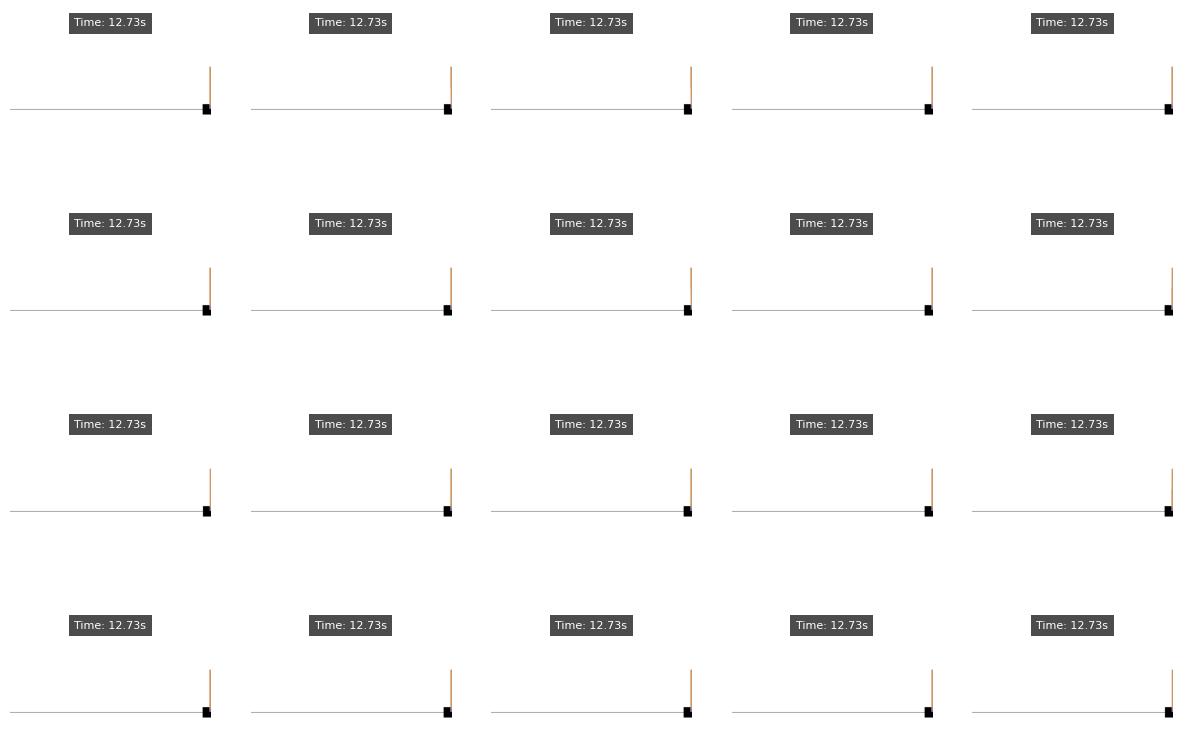

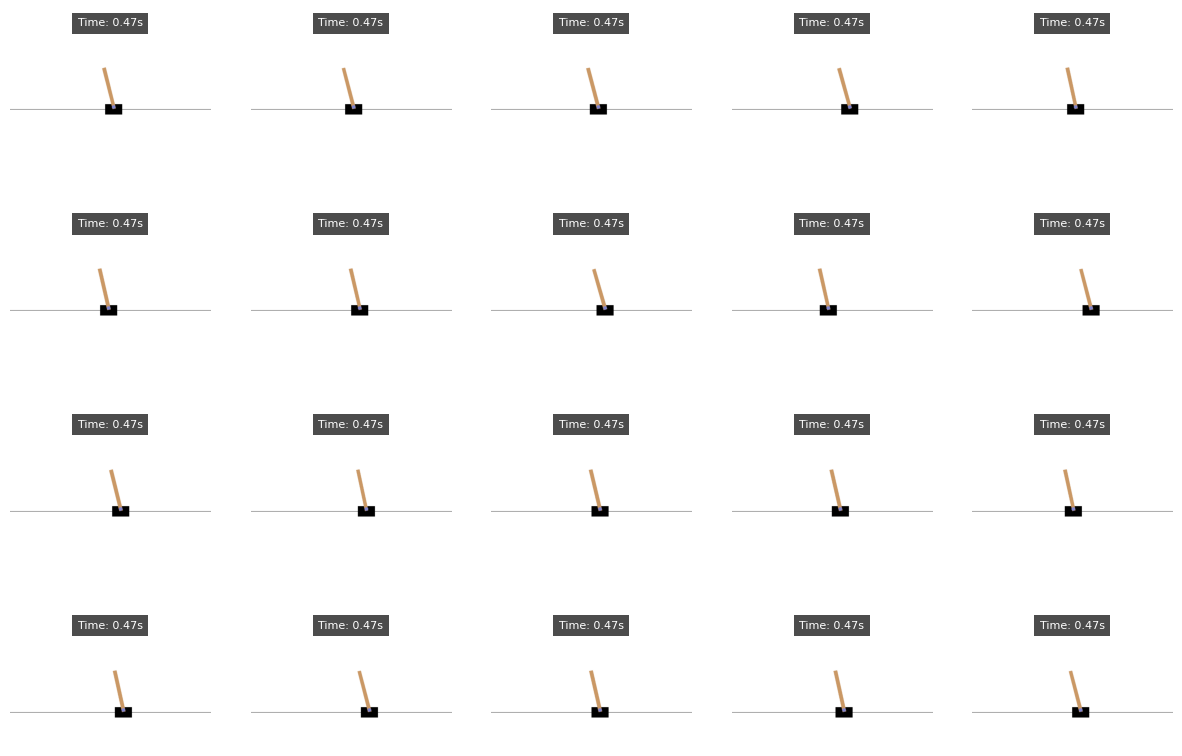

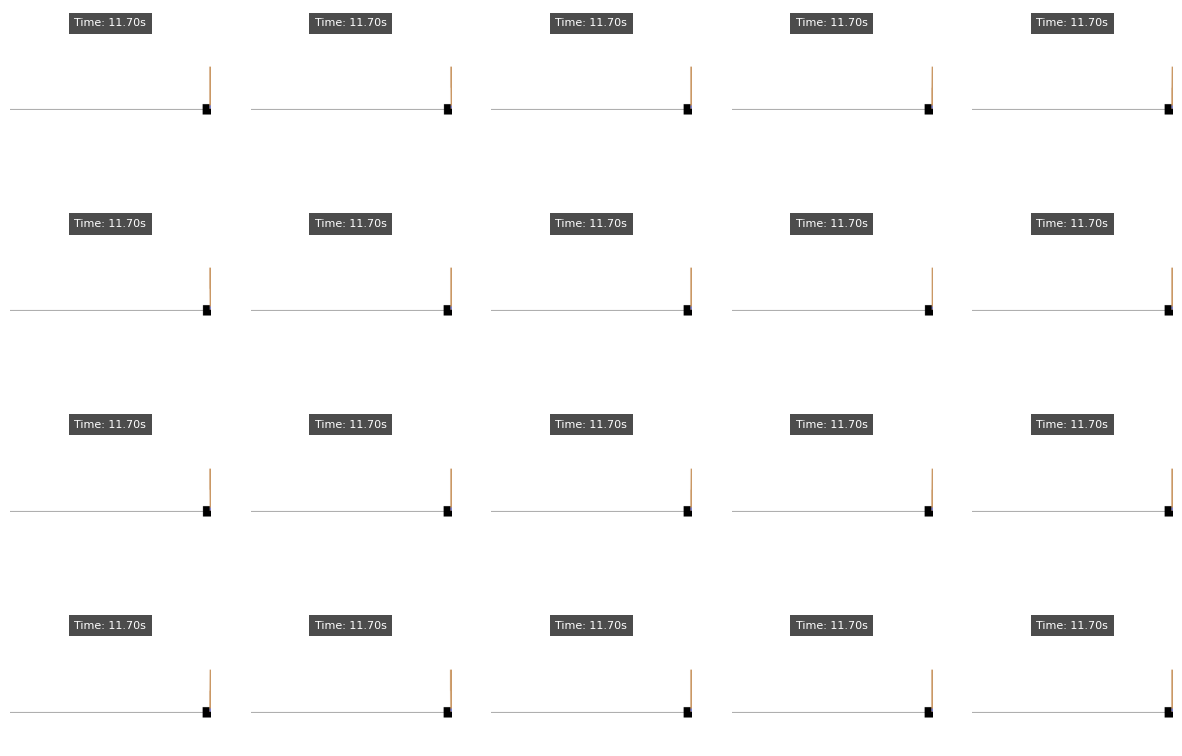

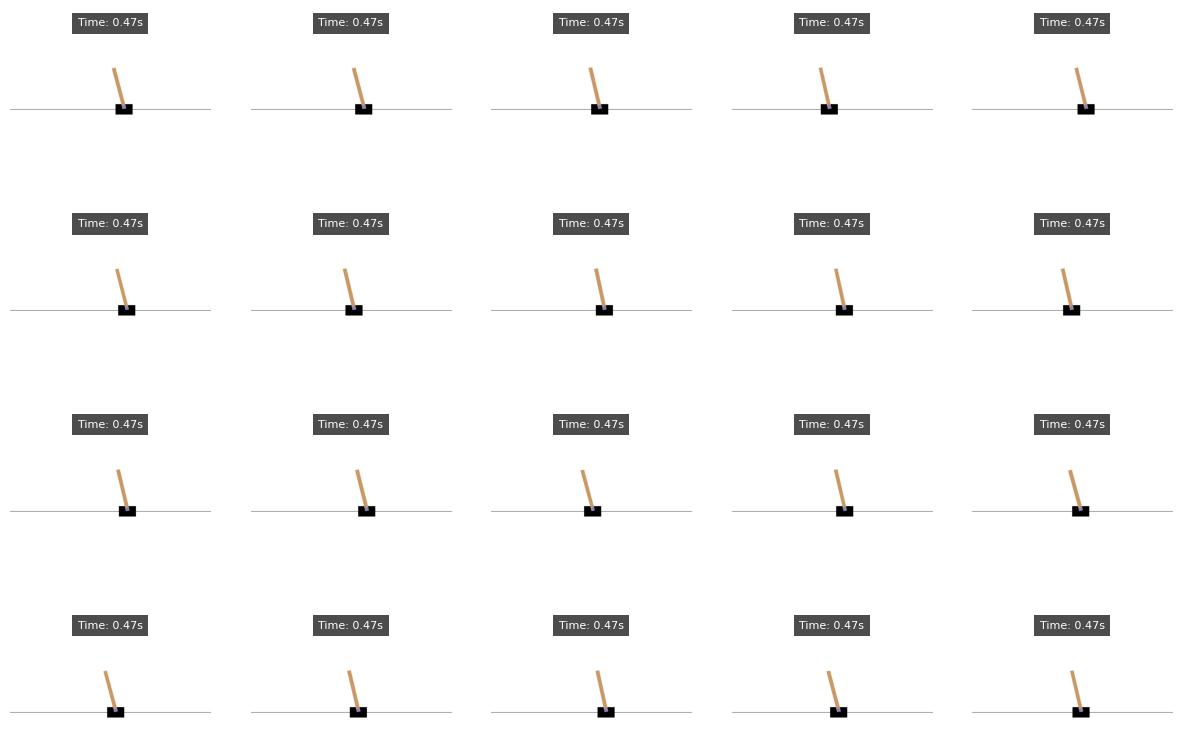

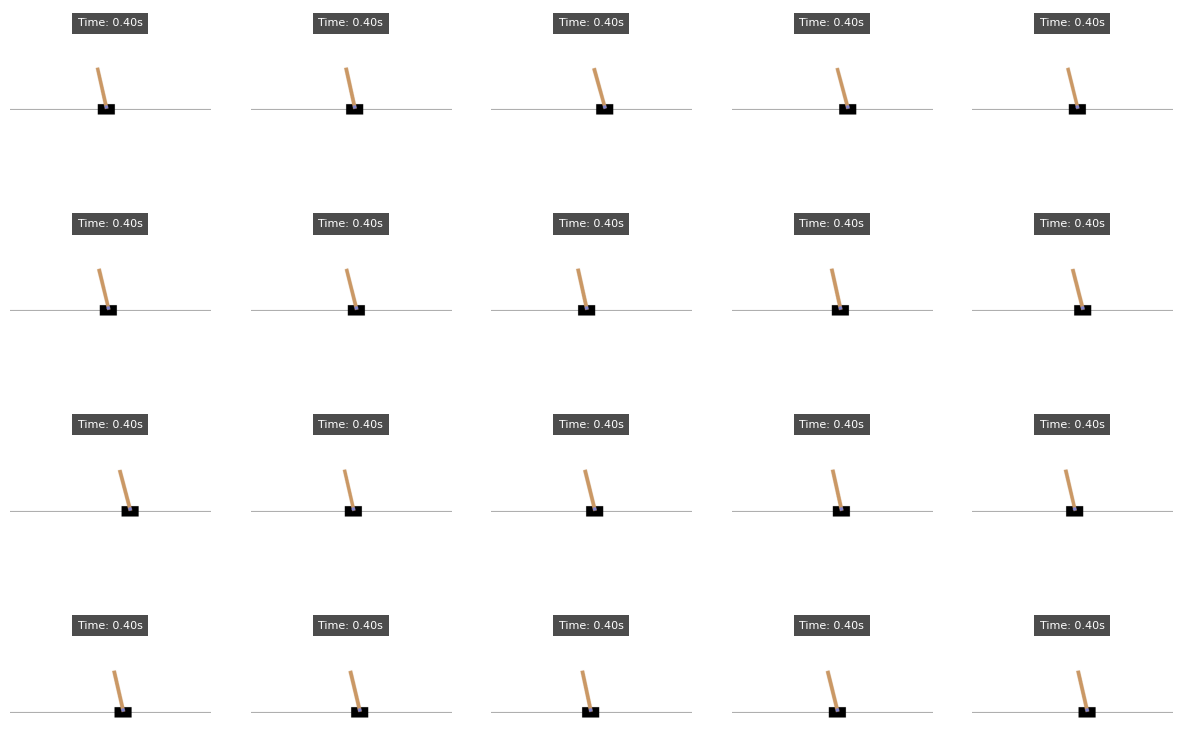

In [ ]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

from Autoencoder import *
from Autoencoder_functions import *
from test_cartpole_function import *

## CHECK RECONSTRUCTION AND MODE PERFORMANCE

# print('Original model')
# test_cartpole_function('../saved_models_re/originals/'+original_model_name, save_imgs=True)

with torch.no_grad():
    kae.eval()
    print('Koopman Autoencoder (reconstruction)')
    reward = test_cartpole_kae_function(kae, observable_dim, padded_dimension, p, device, mode_number = -1, num_episodes = num_episodes, save_imgs = True)
    print(reward)

    for i in range(0,observable_dim):
        print('Koopman Autoencoder mode: '+str(i))
        reward = test_cartpole_kae_function(kae, observable_dim, padded_dimension, p, device, mode_number = i, num_episodes = num_episodes, save_imgs = True)
        print(reward)

In [ ]:
## UNDER CONSTRUCTION BELOW ###############################

import importlib
from Autoencoder_functions import *

%load_ext autoreload
%autoreload 2

sorted_labels, sorted_indices = torch.sort(all_test_labels)
all_test_images_sorted = all_test_images[sorted_indices]
all_test_labels_sorted = sorted_labels
per_label_test_images = {i: all_test_images[all_test_labels == i] for i in range(num_classes)}
per_label_test_labels = {i: all_test_labels[all_test_labels == i] for i in range(num_classes)}

with torch.no_grad():
    for j in range(0,observable_dim):
        result = []
        for cc in range(0,num_classes):
            reconstructed_output_wo_pad = []
            # reconstructed_output_prop_wo_pad = []
            for i in range(0,len(per_label_test_images[cc])):
                _,z,_ = kae(all_test_images[i,:])
                z_next = torch.matmul(z, kae.K.T)
                reconstructed_output = stt_decompose_mode(kae, z, z_next, observable_dim, j, propagation=True)
                reconstructed_output_wo_pad.append(reconstructed_output[:num_classes])

            reconstructed_output_wo_pad = torch.stack(reconstructed_output_wo_pad)
            reconstructed_output_wo_pad_real = reconstructed_output_wo_pad.real.detach()
            predicted = torch.argmax(reconstructed_output_wo_pad_real, dim=1)
            # print(np.shape(reconstructed_output), np.shape(reconstructed_output_wo_pad))
            correct = (predicted == per_label_test_labels[cc]).sum().item()
            total = all_test_labels.size(0)
            accuracy = 100.0 * correct / total
            result.append(accuracy)
        print(str(j)+"-th mode "+str(result))


In [ ]:

print()

predicted = torch.argmax(reconstructed_output_wo_pad, dim=1)
print(np.shape(reconstructed_output), np.shape(reconstructed_output_wo_pad))
print(np.shape(predicted))
correct = (predicted == all_test_labels).sum().item()
total = all_test_labels.size(0)
accuracy = 100.0 * correct / total
print(accuracy)

In [ ]:

    for idx_modes in tqdm(range(kae_size)):
        temp = np.zeros(num_classes)
        
        for idx_sub in range(num_classes):
            param_sub = param_sub_all[:, idx_modes]
            if target_dataset == 'MNIST_DEEP':
                classifier_sub_test = deepdeeper_MLP(image_size, hidden_c, num_classes).to(device)
            else:   
                classifier_sub_test = deeper_MLP(image_size, hidden_c, num_classes).to(device)
            classifier_sub_test.eval()
            nn.utils.vector_to_parameters(param_sub, classifier_sub_test.parameters())
            testloader = dataset_in_use_per_class.sub_testloaders[idx_sub]
            total = 0
            correct = 0
            for images, labels in testloader:
                images = images.reshape(-1, 28*28).to(device)
                labels = labels.to(device)
                outputs = classifier_sub_test(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
            accuracy = 100 * correct / total
            temp[idx_sub] = accuracy
        formatted = np.array([num for num in temp])

        if idx_modes == 0:
            formatted_history = formatted
        else:
            formatted_history = np.vstack((formatted_history, formatted))

# Get best element
formatted_history2 = np.array(formatted_history, dtype=float)
bests = np.max(formatted_history2,axis = 0)
is_max = formatted_history2 == bests
row_counts = np.sum(is_max, axis = 1)

print('Best elements :')
print(bests)
print('Best counts :')
print(row_counts)

num_cols = formatted_history2.shape[1]
for col in range(num_cols):
    rows_with_max = np.where(formatted_history2[:,col] == bests[col])[0]
    print('------------')
    print(f'Class {col}: Best = {bests[col]}')
    for row_idx in rows_with_max:
        print(f'Mode {row_idx}: [|eig|={torch.linalg.norm(eigvals_d[row_idx])}] {np.array2string(formatted_history2[row_idx], precision=4)}')